In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.metrics import root_mean_squared_error

import common
from model.features import add_time_features, build_abnormal_dates
from model.preprocessing import transform_target


In [2]:
CSV_PATH = f"{common.CONFIG['paths']['raw_data']}/{common.CONFIG['dataset']['csv_file']}"
RANDOM_STATE = int(common.CONFIG["ml"]["random_state"])


In [3]:
data = pd.read_csv(CSV_PATH)
data = data.drop(columns=["id", "dropoff_datetime"])
data["pickup_datetime"] = pd.to_datetime(data["pickup_datetime"])

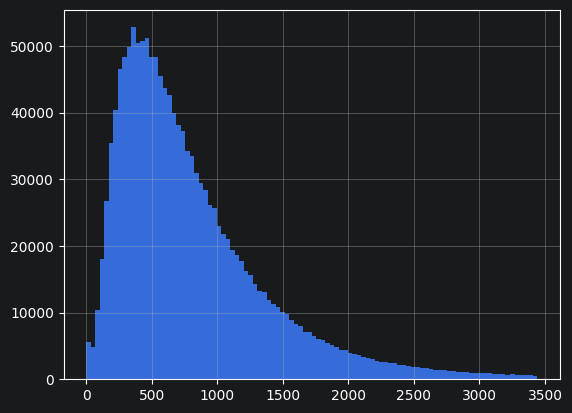

In [4]:
# distribution of target
data.trip_duration[data.trip_duration < data.trip_duration.quantile(0.99)].hist(bins=100)
plt.show()

In [5]:
X = data.drop(columns=["trip_duration"])
y = data["trip_duration"]

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.3,
    random_state=RANDOM_STATE,
)

In [8]:
y = transform_target(y)
y_train = transform_target(y_train)
y_test = transform_target(y_test)

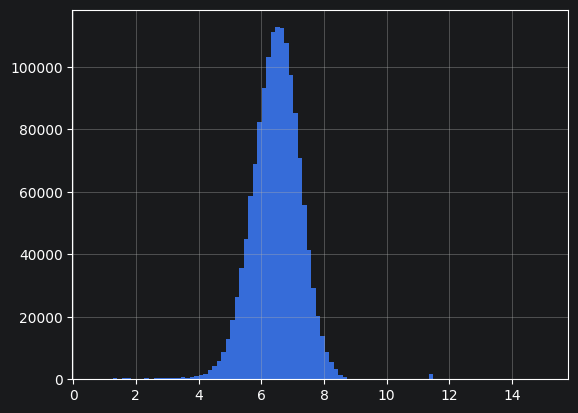

In [9]:
y.hist(bins=100)
plt.show()


In [10]:
# baseline
y_baseline = y_train.mean()
print(f"Baseline prediction: {y_baseline:.2f} (transformed)")
print(f"Baseline prediction: {np.expm1(y_baseline):.0f} (seconds)")
print(f"RMSLE on train data: {root_mean_squared_error([y_baseline] * len(y_train), y_train):.3f}")
print(f"RMSLE on test data: {root_mean_squared_error([y_baseline] * len(y_test), y_test):.3f}")


Baseline prediction: 6.47 (transformed)
Baseline prediction: 643 (seconds)
RMSLE on train data: 0.796
RMSLE on test data: 0.795


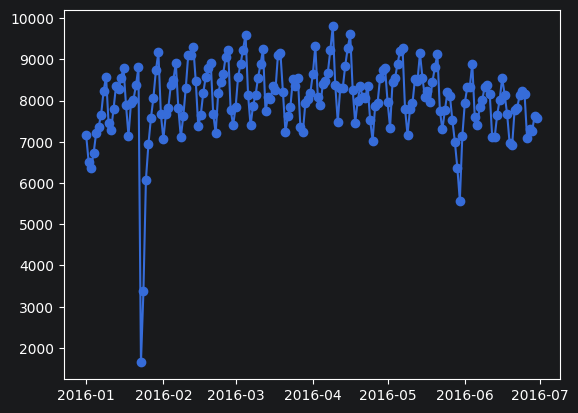

In [11]:
# trips by date
X["pickup_date"] = X["pickup_datetime"].dt.date
plt.plot(X["pickup_date"].groupby(X["pickup_date"]).count(), "o-")
plt.show()


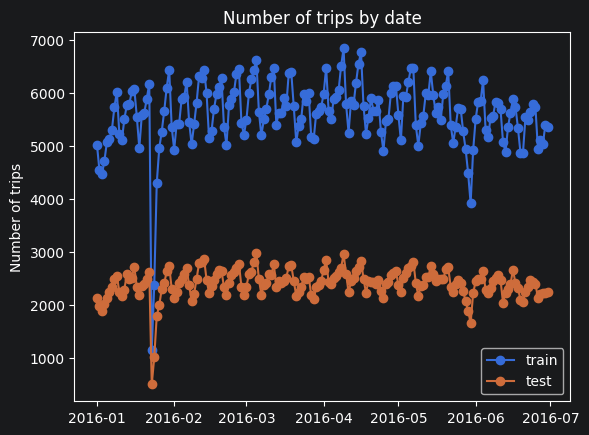

In [12]:
plt.plot(X_train["pickup_datetime"].groupby(X_train["pickup_datetime"].dt.date).count(), "o-", label="train")
plt.plot(X_test["pickup_datetime"].groupby(X_test["pickup_datetime"].dt.date).count(), "o-", label="test")
plt.title("Number of trips by date")
plt.legend(loc=0)
plt.ylabel("Number of trips")
plt.show()

In [13]:
abnormal_dates = build_abnormal_dates(X)
print(abnormal_dates)

Index([2016-01-23, 2016-01-24, 2016-01-25, 2016-05-30], dtype='object', name='pickup_date')


In [14]:
dict_weekday = {
    0: "Monday",
    1: "Tuesday",
    2: "Wednesday",
    3: "Thursday",
    4: "Friday",
    5: "Saturday",
    6: "Sunday",
}

In [15]:
weekday_num = X["pickup_datetime"].dt.weekday
weekday = X["pickup_datetime"].dt.weekday.map(dict_weekday).rename("weekday")
hourofday = X["pickup_datetime"].dt.hour.rename("hour")


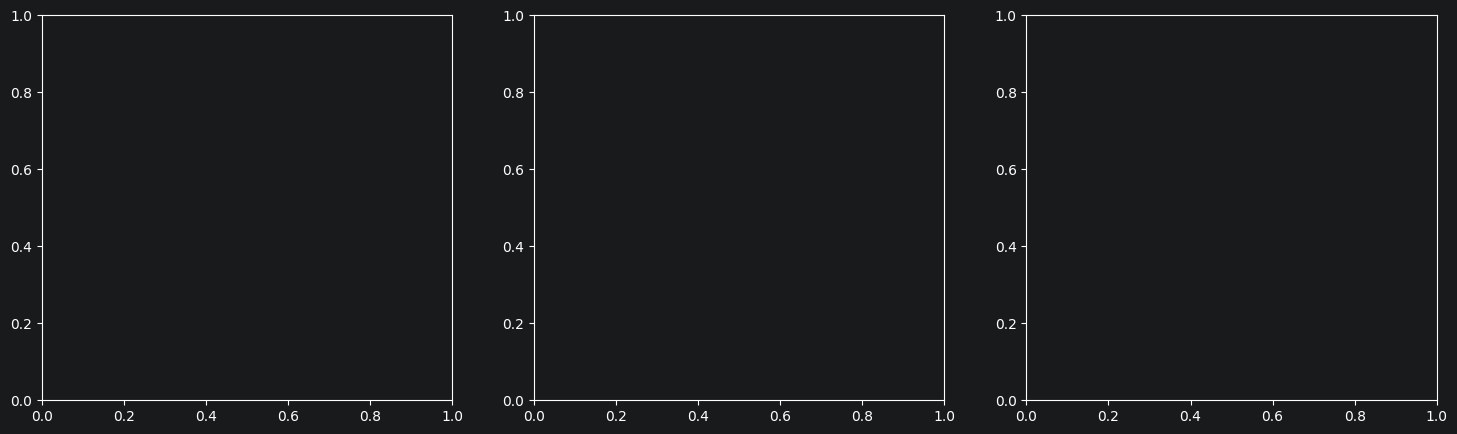

In [16]:
fig, ax = plt.subplots(1, 3, figsize=(18, 5))

In [17]:
sns.countplot(x=weekday_num, ax=ax[0])
ax[0].set(xlabel="weekday_num")
ax[0].tick_params("x", labelrotation=45)

In [18]:
sns.countplot(x=weekday, ax=ax[1])
ax[1].set(xlabel="weekday")
ax[1].tick_params("x", labelrotation=45)

In [19]:
sns.countplot(x=hourofday, ax=ax[2])
ax[2].set(xlabel="hour")
ax[2].tick_params("x", labelrotation=90)

In [20]:
plt.show()

In [21]:
# Keep time enrichment simple and readable before trying more complex geo features.
X = add_time_features(X, abnormal_dates)
X_train = add_time_features(X_train, abnormal_dates)
X_test = add_time_features(X_test, abnormal_dates)

In [22]:
# Inspect both raw calendar fields and engineered time signals used by the model.
print(
    X[
        [
            "pickup_datetime",
            "weekday",
            "month",
            "hour",
            "is_weekend",
            "time_bucket",
            "hour_sin",
            "hour_cos",
            "is_holiday",
            "is_pre_holiday",
            "is_post_holiday",
            "abnormal_period",
        ]
    ].head()
)
print(X["weekday"].value_counts().head())
print(X["month"].value_counts().head())
print(X["hour"].value_counts().head())
print(X["time_bucket"].value_counts())
print(X["is_holiday"].value_counts())
print(X["abnormal_period"].value_counts())


      pickup_datetime  weekday  month  hour  is_weekend   time_bucket  \
0 2016-03-14 17:24:55        0      3    17           0  evening_peak   
1 2016-06-12 00:43:35        6      6     0           1    late_night   
2 2016-01-19 11:35:24        1      1    11           0        midday   
3 2016-04-06 19:32:31        2      4    19           0  evening_peak   
4 2016-03-26 13:30:55        5      3    13           1        midday   

   hour_sin  hour_cos  is_holiday  is_pre_holiday  is_post_holiday  \
0 -0.965926 -0.258819           0               0                0   
1  0.000000  1.000000           0               0                0   
2  0.258819 -0.965926           0               0                1   
3 -0.965926  0.258819           0               0                0   
4 -0.258819 -0.965926           0               0                0   

   abnormal_period  
0                0  
1                0  
2                0  
3                0  
4                0  
weekday
4    2